In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import pvlib
import json

from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [3]:
# --- 1. Initial Data Loading and Merging for Training Data (df_2107) ---
dataframes = {}
file_paths = [
    "content/2107_meterdatatr.csv",
    "content/2107_irrdatatr.csv",
    "content/2107_envdatatr.csv"
]

for file_path in file_paths:
    try:
        df_name = os.path.basename(file_path).split('.')[0]
        df_temp = pd.read_csv(file_path)
        if 'Unnamed: 0' in df_temp.columns:
            df_temp = df_temp.rename(columns={'Unnamed: 0': 'measured_on'})
        dataframes[df_name] = df_temp
        print(f"Successfully loaded and processed {file_path}")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

df_2107 = pd.DataFrame()
base_df_name = None

if '2107_meterdatatr' in dataframes and 'measured_on' in dataframes['2107_meterdatatr'].columns:
    df_2107 = dataframes['2107_meterdatatr'].copy()
    base_df_name = '2107_meterdatatr'
    print(f"Initialized df_2107 with {base_df_name}.")
elif '2107_irrdatatr' in dataframes and 'measured_on' in dataframes['2107_irrdatatr'].columns:
    df_2107 = dataframes['2107_irrdatatr'].copy()
    base_df_name = '2107_irrdatatr'
    print(f"Initialized df_2107 with {base_df_name}.")
else:
    for name, df in dataframes.items():
        if 'measured_on' in df.columns:
            df_2107 = df.copy()
            base_df_name = name
            print(f"Initialized df_2107 with {base_df_name}.")
            break

if df_2107.empty:
    print("Warning: No suitable base dataframe with 'measured_on' column found, starting with empty DataFrame.")
else:
    for df_name, df_to_merge in dataframes.items():
        if df_name != base_df_name:
            if 'measured_on' in df_to_merge.columns:
                df_2107 = pd.merge(df_2107, df_to_merge, on='measured_on', how='outer')
                print(f"Merged {df_name}")
            else:
                print(f"Skipping merge for {df_name}: 'measured_on' column missing in this dataframe.")

if 'measured_on' in df_2107.columns:
    df_2107['measured_on'] = pd.to_datetime(df_2107['measured_on'])
    df_2107 = df_2107.set_index('measured_on')
    print("Converted 'measured_on' to datetime index.")
else:
    print("Warning: 'measured_on' column not found, cannot set as datetime index.")

df_2107 = df_2107.sort_index()
print("Data sorted chronologically by index.")

missing_values = df_2107.isnull().sum()
print("\nMissing values after initial merging and sorting (df_2107):\n")
print(missing_values[missing_values > 0])
print("\nFirst 5 rows of df_2107 after initial loading:\n")
display(df_2107.head())

# --- 2. Define Column Mapping and Descriptions ---
column_mapping = {
    'meter_revenue_grade_ac_output_meter_149578': 'ac_output_kw',
    'poa_irradiance_o_149574': 'poa_irradiance',
    'ambient_temperature_o_149575': 'ambient_temp_f',
    'wind_speed_o_149576': 'wind_speed_mph',
    'wind_direction_o_149577': 'wind_direction_deg'
}

column_descriptions = {
    'measured_on': 'Timestamp of the measurement.',
    'ac_output_kw': 'AC Power Output in kilowatts. This is the primary target variable for forecasting.',
    'poa_irradiance': 'Plane of Array (POA) Irradiance, typically in Watts per square meter.',
    'ambient_temp_f': 'Ambient (outdoor) temperature, typically in degrees Fahrenheit.',
    'wind_speed_mph': 'Wind speed, typically in miles per hour.',
    'wind_direction_deg': 'Wind direction, typically in degrees (0-360).'
}

# --- 3. Load Metadata and Enrich Descriptions for df_2107 ---
metadata_path = 'uplo/2107_system_metadata.json'
metadata = {}
try:
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(f"\nSuccessfully loaded metadata from {metadata_path}")
except FileNotFoundError:
    print(f"\nMetadata file not found at {metadata_path}. Proceeding without metadata.")
except json.JSONDecodeError:
    print(f"\nError decoding JSON from {metadata_path}. Proceeding without metadata.")
except Exception as e:
    print(f"\nAn unexpected error occurred while loading metadata: {e}. Proceeding without metadata.")

def get_sensor_info(sensor_id, metadata_list):
    for sensor in metadata_list:
        if sensor.get('id') == sensor_id:
            return sensor
    return None

if metadata and 'sensors' in metadata:
    sensors_metadata = metadata['sensors']
    original_cols_to_sensor_ids = {
        'meter_revenue_grade_ac_output_meter_149578': '149578',
        'poa_irradiance_o_149574': '149574',
        'ambient_temperature_o_149575': '149575',
        'wind_speed_o_149576': '149576',
        'wind_direction_o_149577': '149577'
    }
    for original_col, sensor_id in original_cols_to_sensor_ids.items():
        sensor_info = get_sensor_info(sensor_id, sensors_metadata)
        if sensor_info:
            new_col_name = column_mapping.get(original_col)
            if new_col_name:
                metric = sensor_info.get('metric', new_col_name.replace('_', ' ').title())
                unit = sensor_info.get('unit', '')
                desc_detail = sensor_info.get('description', '')
                enriched_desc = f"{metric}"
                if unit:
                    enriched_desc += f" ({unit})"
                if desc_detail:
                    enriched_desc += f". {desc_detail}"
                if new_col_name == 'ac_output_kw':
                    enriched_desc += " This is the primary target variable for forecasting."
                column_descriptions[new_col_name] = enriched_desc

print("\n--- Column Descriptions ---")
for col, desc in column_descriptions.items():
    if col in df_2107.columns or (df_2107.index.name == col):
        print(f"- **{col}**: {desc}")

df_2107 = df_2107.rename(columns=column_mapping)
print("\n--- df_2107 Head after renaming ---")
display(df_2107.head())

# Extract location and timezone from metadata
print("\nMetadata structure for debugging:")
print(json.dumps(metadata, indent=2))

latitude = metadata['Site'].get('latitude', None)
longitude = metadata['Site'].get('longitude', None)
altitude = metadata['Site'].get('elevation(m)', None)
timezone = metadata['System'].get('timezone_code', None)

if None in [latitude, longitude, altitude, timezone]:
    raise ValueError("Could not extract all necessary location/timezone information from metadata.")

print(f"Using location: Latitude={latitude}, Longitude={longitude}, Altitude={altitude}, Timezone={timezone}")

# Localize df_2107 index and calculate solar position
if df_2107.index.tz is None:
    df_2107.index = df_2107.index.tz_localize(timezone, ambiguous='NaT', nonexistent='NaT')
else:
    df_2107.index = df_2107.index.tz_convert(timezone)

solpos_2107 = pvlib.solarposition.get_solarposition(
    time=df_2107.index,
    latitude=latitude,
    longitude=longitude,
    altitude=altitude,
    temperature=df_2107['ambient_temp_f']
)

df_2107['solar_elevation'] = solpos_2107['elevation']
df_2107['solar_apparent_elevation'] = solpos_2107['apparent_elevation']
df_2107['solar_zenith'] = solpos_2107['zenith']
df_2107['solar_azimuth'] = solpos_2107['azimuth']

print("Added solar position features to df_2107.")
print("Head of df_2107 with new solar features:")
display(df_2107.head())

# --- 4. Load and Preprocess Test Data (df_test) ---
test_file_path = 'uplo/test/2107_mergeddatates.csv'
df_test_raw = pd.read_csv(test_file_path)

if 'Unnamed: 0' in df_test_raw.columns:
    df_test_raw = df_test_raw.rename(columns={'Unnamed: 0': 'measured_on'})

df_test_raw['measured_on'] = pd.to_datetime(df_test_raw['measured_on'])
df_test = df_test_raw.set_index('measured_on')
df_test = df_test.rename(columns=column_mapping)
df_test = df_test.sort_index()

print(f"\nSuccessfully loaded and preprocessed test data from {test_file_path}")
print(f"Shape of test data: {df_test.shape}")
print("\nFirst 5 rows of the test DataFrame (df_test):\n")
display(df_test.head())

# --- 5. Localize df_test index and Calculate Solar Position for df_test ---
if df_test.index.tz is None:
    df_test.index = df_test.index.tz_localize(timezone, ambiguous='NaT', nonexistent='NaT')
else:
    df_test.index = df_test.index.tz_convert(timezone)

solpos_test = pvlib.solarposition.get_solarposition(
    time=df_test.index,
    latitude=latitude,
    longitude=longitude,
    altitude=altitude,
    temperature=df_test['ambient_temp_f']
)

df_test['solar_elevation'] = solpos_test['elevation']
df_test['solar_apparent_elevation'] = solpos_test['apparent_elevation']
df_test['solar_zenith'] = solpos_test['zenith']
df_test['solar_azimuth'] = solpos_test['azimuth']

print("Added solar position features to df_test.")
print("Head of df_test with new solar features:")
display(df_test.head())

# --- 6. Combine df_2107 and df_test ---
df_combined_full = pd.concat([df_2107, df_test], axis=0)
df_combined_full = df_combined_full.sort_index()

# Interpolate missing solar position values
columns_to_interpolate = ['solar_elevation', 'solar_apparent_elevation', 'solar_zenith', 'solar_azimuth']
for col in columns_to_interpolate:
    if df_combined_full[col].isnull().any():
        df_combined_full[col] = df_combined_full[col].interpolate(method='linear')
        print(f"Interpolated missing values in {col}")

# Check and remove any rows with NaT in the index
initial_rows = df_combined_full.shape[0]
df_combined_full = df_combined_full[df_combined_full.index.notna()]
removed_rows = initial_rows - df_combined_full.shape[0]
if removed_rows > 0:
    print(f"Removed {removed_rows} rows from df_combined_full due to NaT values in the index.")
else:
    print("No NaT values found in df_combined_full index.")

print(f"\nShape of combined DataFrame (df_combined_full): {df_combined_full.shape}")
print("\nFirst 5 rows of the combined DataFrame (df_combined_full):\n")
display(df_combined_full.head())
print("\nLast 5 rows of the combined DataFrame (df_combined_full):\n")
display(df_combined_full.tail())

Successfully loaded and processed content/2107_meterdatatr.csv
Successfully loaded and processed content/2107_irrdatatr.csv
Successfully loaded and processed content/2107_envdatatr.csv
Initialized df_2107 with 2107_meterdatatr.
Merged 2107_irrdatatr
Merged 2107_envdatatr
Converted 'measured_on' to datetime index.
Data sorted chronologically by index.

Missing values after initial merging and sorting (df_2107):

Series([], dtype: int64)

First 5 rows of df_2107 after initial loading:



,meter_revenue_grade_ac_output_meter_149578,poa_irradiance_o_149574,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
measured_on,,,,,
2020-01-01 00:00:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:15:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:30:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:45:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 01:00:00,0.0,0.0,43.6,2.1,290.0



Successfully loaded metadata from uplo/2107_system_metadata.json

--- Column Descriptions ---
- **measured_on**: Timestamp of the measurement.

--- df_2107 Head after renaming ---


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg
measured_on,,,,,
2020-01-01 00:00:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:15:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:30:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 00:45:00,0.0,0.0,44.3,2.3,196.0
2020-01-01 01:00:00,0.0,0.0,43.6,2.1,290.0



Metadata structure for debugging:
{
  "System": {
    "system_id": 2107,
    "public_name": "Farm Solar Array",
    "power(kW DC)": 893.0,
    "started_on": "2017-01-01 00:00:00",
    "comments": "Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023",
    "data_prize": "t",
    "timezone_code": "PST8PDT",
    "us_region": "West",
    "agripv": "f",
    "first_timestamp": "2018-12-15 00:15:00",
    "last_timestamp": "2023-11-15 12:21:50",
    "years_of_data": 4.9205,
    "data_time_resolution": "5-15 min",
    "number_data_channels": 125,
    "data_size": "445 MB"
  },
  "Site": {
    "site_id": 7211,
    "public_name": "FSA_1",
    "location": "Arbuckle, CA",
    "us_region": "West",
    "latitude": 38.996306,
    "longitude": -122.134111,
    "elevation(m)": 10.0,
    "climate_type": "Csa"
  },
  "Mount": {
    "Mount 0": {
      "mount_id": 17263,
      "name": "mnt_fss_1",
      "manufacturer": "Schletter",
      

...

,ambient_temp_f,wind_speed_mph,wind_direction_deg,poa_irradiance,ac_output_kw,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2022-01-01 00:00:00-08:00,36.5,5.7,16.0,0.0,0.0,-73.794896,-73.794896,163.794896,350.063055
2022-01-01 00:15:00-08:00,36.5,5.7,16.0,0.0,0.0,-73.983671,-73.983671,163.983671,2.502446
2022-01-01 00:30:00-08:00,36.5,5.7,16.0,0.0,0.0,-73.543732,-73.543732,163.543732,14.766121
2022-01-01 00:45:00-08:00,36.5,5.7,16.0,0.0,0.0,-72.522955,-72.522955,162.522955,26.083855
2022-01-01 01:00:00-08:00,36.2,5.0,323.0,0.0,0.0,-71.015850,-71.015850,161.015850,36.026137


Interpolated missing values in solar_elevation
Interpolated missing values in solar_apparent_elevation
Interpolated missing values in solar_zenith
Interpolated missing values in solar_azimuth
Removed 24 rows from df_combined_full due to NaT values in the index.

Shape of combined DataFrame (df_combined_full): (105192, 9)

First 5 rows of the combined DataFrame (df_combined_full):



,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761



Last 5 rows of the combined DataFrame (df_combined_full):



,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2022-12-31 22:45:00-08:00,0.0,0.0,48.8,4.5,260.0,-65.589560,-65.589560,155.589560,304.516142
2022-12-31 23:00:00-08:00,0.0,0.0,49.9,9.4,265.0,-67.893321,-67.893321,157.893321,311.030505
2022-12-31 23:15:00-08:00,0.0,0.0,49.9,9.4,265.0,-69.959350,-69.959350,159.959350,318.728950
2022-12-31 23:30:00-08:00,0.0,0.0,49.9,9.4,265.0,-71.704057,-71.704057,161.704057,327.811626
2022-12-31 23:45:00-08:00,0.0,0.0,49.9,9.4,265.0,-73.025712,-73.025712,163.025712,338.351960


In [41]:
df_combined_full.describe(include='all').T



# Provide a descriptive statistics summary for all columns in the `df_combined_full` DataFrame, including count, mean, standard deviation, min, max, and quartiles.

,count,mean,std,min,25%,50%,75%,max
ac_output_kw,105192.0,157.734298,228.703028,0.000000,0.000000,0.000000,317.440000,708.480000
poa_irradiance,105192.0,251.015883,347.862436,0.000000,0.000000,8.200000,503.700000,1400.000000
ambient_temp_f,105192.0,62.587322,16.389488,23.400000,49.800000,61.300000,74.000000,115.600000
wind_speed_mph,105192.0,5.808679,4.146371,1.000000,2.900000,4.300000,7.500000,27.700000
wind_direction_deg,105192.0,188.117461,98.251166,0.000000,124.000000,165.000000,269.000000,360.000000
solar_elevation,105192.0,0.299504,36.626493,-74.380938,-28.482057,0.209226,29.080921,74.409882
solar_apparent_elevation,105192.0,0.326461,36.635136,-74.380938,-28.482057,0.596705,29.106844,74.413461
solar_zenith,105192.0,89.700496,36.626493,15.590118,60.919079,89.790774,118.482057,164.380938
solar_azimuth,105192.0,179.884569,100.677272,0.003422,89.624124,180.032277,270.162167,359.995817


In [ ]:
df_combined_full.info()

# Display a concise summary of the `df_combined_full` DataFrame, including data types, non-null values, and memory usage, to quickly understand its structure.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105192 entries, 2020-01-01 00:00:00-08:00 to 2022-12-31 23:45:00-08:00
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ac_output_kw              105192 non-null  float64
 1   poa_irradiance            105192 non-null  float64
 2   ambient_temp_f            105192 non-null  float64
 3   wind_speed_mph            105192 non-null  float64
 4   wind_direction_deg        105192 non-null  float64
 5   solar_elevation           105192 non-null  float64
 6   solar_apparent_elevation  105192 non-null  float64
 7   solar_zenith              105192 non-null  float64
 8   solar_azimuth             105192 non-null  float64
dtypes: float64(9)
memory usage: 8.0 MB


In [43]:
print("DataFrame Index Information:")
print(f"Index type: {df_combined_full.index}")
print(f"Index name: {df_combined_full.index.name}")
print(f"Is index a DatetimeIndex: {isinstance(df_combined_full.index, pd.DatetimeIndex)}")
print(f"Is index sorted (monotonically increasing): {df_combined_full.index.is_monotonic_increasing}")



# Confirm that the DataFrame's index is a DatetimeIndex, is named 'measured_on', and is sorted in monotonically increasing order, validating the previous time-series preprocessing steps.

DataFrame Index Information:
Index type: DatetimeIndex(['2020-01-01 00:00:00-08:00', '2020-01-01 00:15:00-08:00',
               '2020-01-01 00:30:00-08:00', '2020-01-01 00:45:00-08:00',
               '2020-01-01 01:00:00-08:00', '2020-01-01 01:15:00-08:00',
               '2020-01-01 01:30:00-08:00', '2020-01-01 01:45:00-08:00',
               '2020-01-01 02:00:00-08:00', '2020-01-01 02:15:00-08:00',
               ...
               '2022-12-31 21:30:00-08:00', '2022-12-31 21:45:00-08:00',
               '2022-12-31 22:00:00-08:00', '2022-12-31 22:15:00-08:00',
               '2022-12-31 22:30:00-08:00', '2022-12-31 22:45:00-08:00',
               '2022-12-31 23:00:00-08:00', '2022-12-31 23:15:00-08:00',
               '2022-12-31 23:30:00-08:00', '2022-12-31 23:45:00-08:00'],
              dtype='datetime64[ns, PST8PDT]', name='measured_on', length=105192, freq=None)
Index name: measured_on
Is index a DatetimeIndex: True
Is index sorted (monotonically increasing): True


In [4]:
# Filter for training data (years 2020 and 2021)
train_df = df_combined_full.loc['2020-01-01':'2021-12-31']

# Filter for test data (year 2022)
test_df = df_combined_full.loc['2022-01-01':'2022-12-31']

print(f"Shape of training data (2020-2021): {train_df.shape}")
print(f"Shape of test data (2022): {test_df.shape}")

print("\nHead of Training Data:")
display(train_df.head())

print("\nHead of Test Data:")
display(test_df.head())



# Split the `df_combined_full` DataFrame into `train_df` (years 2020-2021) and `test_df` (year 2022) for subsequent model training and evaluation.

Shape of training data (2020-2021): (70160, 9)
Shape of test data (2022): (35032, 9)

Head of Training Data:


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761



Head of Test Data:


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2022-01-01 00:00:00-08:00,0.0,0.0,36.5,5.7,16.0,-73.794896,-73.794896,163.794896,350.063055
2022-01-01 00:15:00-08:00,0.0,0.0,36.5,5.7,16.0,-73.983671,-73.983671,163.983671,2.502446
2022-01-01 00:30:00-08:00,0.0,0.0,36.5,5.7,16.0,-73.543732,-73.543732,163.543732,14.766121
2022-01-01 00:45:00-08:00,0.0,0.0,36.5,5.7,16.0,-72.522955,-72.522955,162.522955,26.083855
2022-01-01 01:00:00-08:00,0.0,0.0,36.2,5.0,323.0,-71.015850,-71.015850,161.015850,36.026137


In [5]:
na = df_combined_full[df_combined_full.isna().any(axis=1)]

print(f'Percentage of rows with missing values: {round(len(na)/len(df_combined_full) * 100,2)}%')
na



# Check for rows with any missing values in `df_combined_full` and calculates the percentage of such rows. The output confirms there are no missing values.

Percentage of rows with missing values: 0.0%


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,


In [6]:
df_combined_full

# This cell simply displays the entire `df_combined_full` DataFrame, showing its current state after initial data ingestion, renaming, and sorting.

,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761
...,...,...,...,...,...,...,...,...,...
2022-12-31 22:45:00-08:00,0.0,0.0,48.8,4.5,260.0,-65.589560,-65.589560,155.589560,304.516142
2022-12-31 23:00:00-08:00,0.0,0.0,49.9,9.4,265.0,-67.893321,-67.893321,157.893321,311.030505
2022-12-31 23:15:00-08:00,0.0,0.0,49.9,9.4,265.0,-69.959350,-69.959350,159.959350,318.728950


Label suspicious zero-power daytime periods as missing-data artifacts

This section flags daytime records where **POA irradiance is present but AC power is zero**, groups consecutive suspicious runs, labels longer runs as **missing-data artifacts**, and interpolates the target signal to avoid training the forecasting models on physically implausible zero-output periods.

In [7]:
# Create the target variable 'y'
y = df_combined_full['ac_output_kw']

# Create the features DataFrame 'X' by dropping the target variable
X = df_combined_full.drop('ac_output_kw', axis=1)

print("Target variable (y) head:")
display(y.head())

print("\nFeatures DataFrame (X) head:")
display(X.head())

# Separate the 'ac_output_kw' column into the target variable 'y' and the remaining columns into the features DataFrame 'X', preparing the data for machine learning modeling.

Target variable (y) head:


measured_on
2020-01-01 00:00:00-08:00    0.0
2020-01-01 00:15:00-08:00    0.0
2020-01-01 00:30:00-08:00    0.0
2020-01-01 00:45:00-08:00    0.0
2020-01-01 01:00:00-08:00    0.0
Name: ac_output_kw, dtype: float64


Features DataFrame (X) head:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,
2020-01-01 00:00:00-08:00,0.0,44.3,2.3,196.0,-73.841620,-73.841620,163.841620,350.218378
2020-01-01 00:15:00-08:00,0.0,44.3,2.3,196.0,-74.021761,-74.021761,164.021761,2.687778
2020-01-01 00:30:00-08:00,0.0,44.3,2.3,196.0,-73.572096,-73.572096,163.572096,14.967778
2020-01-01 00:45:00-08:00,0.0,44.3,2.3,196.0,-72.541693,-72.541693,162.541693,26.286888
2020-01-01 01:00:00-08:00,0.0,43.6,2.1,290.0,-71.025987,-71.025987,161.025987,36.219761


In [8]:
# At this point, df_combined_full already contains the cleaned/interpolated
# target signal after labeling suspicious daytime zero-power periods as
# missing-data artifacts in the newly added section above.

# Filter out nighttime/zero irradiance rows where 'poa_irradiance' is 0
df_combined_full_daytime = df_combined_full[df_combined_full['poa_irradiance'] > 0]

# Now create y and X from the filtered daytime data that includes all features
y = df_combined_full_daytime['ac_output_kw']
X = df_combined_full_daytime.drop('ac_output_kw', axis=1)

# --- Shift target (forecast horizon): 1 hour ahead (4 steps for 15-minute data) ---
y = y.shift(-4)

print(f"Original DataFrame shape: {df_combined_full.shape}")
print(f"Daytime DataFrame shape: {df_combined_full_daytime.shape}")

print("\nUpdated Target variable (y) head after filtering and shifting:")
display(y.head())

print("\nUpdated Features DataFrame (X) head after filtering:")
display(X.head())

Original DataFrame shape: (105192, 9)
Daytime DataFrame shape: (55805, 9)

Updated Target variable (y) head after filtering and shifting:


measured_on
2020-01-01 07:30:00-08:00     70.40
2020-01-01 07:45:00-08:00     41.60
2020-01-01 08:00:00-08:00     64.00
2020-01-01 08:15:00-08:00    104.32
2020-01-01 08:30:00-08:00    122.24
Name: ac_output_kw, dtype: float64


Updated Features DataFrame (X) head after filtering:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth
measured_on,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047


In [9]:
X['hour'] = X.index.hour
X['day_of_week'] = X.index.dayofweek
X['day_of_year'] = X.index.dayofyear
X['month'] = X.index.month
X['week_of_year'] = X.index.isocalendar().week.astype(int)
X['year'] = X.index.year


# Hour of day
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

# Day of year
X["doy_sin"] = np.sin(2 * np.pi * X["day_of_year"] / 365.25)
X["doy_cos"] = np.cos(2 * np.pi * X["day_of_year"] / 365.25)

# Wind direction
X["wind_dir_sin"] = np.sin(2 * np.pi * X["wind_direction_deg"] / 360)
X["wind_dir_cos"] = np.cos(2 * np.pi * X["wind_direction_deg"] / 360)


print("Features DataFrame (X) head with new time features:")
display(X.head())



# Perform feature engineering by extracting various time-based features (hour, day of week, day of year, month, week of year, year) from the DataFrame's index and adding them as new columns to the features DataFrame 'X'.

Features DataFrame (X) head with new time features:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,day_of_year,month,week_of_year,year,hour_sin,hour_cos,doy_sin,doy_cos,wind_dir_sin,wind_dir_cos
measured_on,,,,,,,,,,,,,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422,7,2,1,1,1,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047,8,2,1,1,1,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808


In [10]:
X['ac_output_kw_lag1'] = y.shift(1)
X['ac_output_kw_lag2'] = y.shift(2)

X['poa_irradiance_lag1'] = X['poa_irradiance'].shift(1)

print("Features DataFrame (X) head with new lag features:")
display(X.head())



# Create lag features for 'ac_output_kw' (lag1 and lag2) and 'poa_irradiance' (lag1), adding them to the features DataFrame 'X' to incorporate past observations as predictive signals.

Features DataFrame (X) head with new lag features:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,...,year,hour_sin,hour_cos,doy_sin,doy_cos,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag2,poa_irradiance_lag1
measured_on,,,,,,,,,,,,,,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251,7,2,...,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810,NaN,NaN,NaN
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422,7,2,...,2020,0.965926,-0.258819,0.017202,0.999852,-0.874620,-0.484810,70.40,NaN,1.2
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310,8,2,...,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,41.60,70.4,6.0
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194,8,2,...,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,64.00,41.6,13.6
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047,8,2,...,2020,0.866025,-0.500000,0.017202,0.999852,-0.173648,0.984808,104.32,64.0,137.8


In [11]:
# Rolling features for ac_output_kw (solar power)
X['ac_output_kw_roll3'] = y.shift(1).rolling(window=3).mean()
X['ac_output_kw_roll6'] = y.shift(1).rolling(window=6).mean()
X['ac_output_kw_std3']  = y.shift(1).rolling(window=3).std()

# Rolling features for poa_irradiance
X['poa_irradiance_roll3'] = X['poa_irradiance'].shift(1).rolling(window=3).mean()
X['poa_irradiance_roll6'] = X['poa_irradiance'].shift(1).rolling(window=6).mean()

print("Features DataFrame (X) head with new rolling features:")
display(X.head())

print(f"Shape of X before dropping NaNs: {X.shape}")
print(f"Shape of y before dropping NaNs: {y.shape}")

# Calculate and adds various rolling features to the features DataFrame 'X'. It includes rolling mean and standard deviation for 'ac_output_kw' (solar power) and rolling mean for 'poa_irradiance', providing temporal context for forecasting.

Features DataFrame (X) head with new rolling features:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,...,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag2,poa_irradiance_lag1,ac_output_kw_roll3,ac_output_kw_roll6,ac_output_kw_std3,poa_irradiance_roll3,poa_irradiance_roll6
measured_on,,,,,,,,,,,,,,,,,,,,,
2020-01-01 07:30:00-08:00,1.2,42.5,2.3,241.0,-0.400702,0.089195,90.400702,119.821251,7,2,...,-0.874620,-0.484810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 07:45:00-08:00,6.0,42.5,2.3,241.0,2.096892,2.344862,87.903108,122.202422,7,2,...,-0.874620,-0.484810,70.40,NaN,1.2,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:00:00-08:00,13.6,44.8,4.9,350.0,4.529018,4.683792,85.470982,124.654310,8,2,...,-0.173648,0.984808,41.60,70.4,6.0,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:15:00-08:00,137.8,44.8,4.9,350.0,6.889136,7.000633,83.110864,127.184194,8,2,...,-0.173648,0.984808,64.00,41.6,13.6,58.666667,NaN,15.122610,6.933333,NaN
2020-01-01 08:30:00-08:00,101.8,44.8,4.9,350.0,9.170212,9.257204,80.829788,129.799047,8,2,...,-0.173648,0.984808,104.32,64.0,137.8,69.973333,NaN,31.783803,52.466667,NaN


Shape of X before dropping NaNs: (55805, 28)
Shape of y before dropping NaNs: (55805,)


In [12]:
# Combine X and y to drop NaNs consistently across both
df_combined = pd.concat([X, y], axis=1)
df_combined.dropna(inplace=True)

# Separate X and y again after dropping NaNs
X = df_combined.drop('ac_output_kw', axis=1)
y = df_combined['ac_output_kw']

print(f"Shape of X after dropping NaNs: {X.shape}")
print(f"Shape of y after dropping NaNs: {y.shape}")

print("\nFeatures DataFrame (X) head after dropping NaNs:")
display(X.head())

print("\nTarget variable (y) head after dropping NaNs:")
display(y.head())

# Address the NaN values introduced by lagging by combining 'X' and 'y', dropping rows with any NaNs, and then splitting them back into 'X' and 'y' to ensure clean, aligned datasets for modeling.

Shape of X after dropping NaNs: (55795, 28)
Shape of y after dropping NaNs: (55795,)

Features DataFrame (X) head after dropping NaNs:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,...,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag2,poa_irradiance_lag1,ac_output_kw_roll3,ac_output_kw_roll6,ac_output_kw_std3,poa_irradiance_roll3,poa_irradiance_roll6
measured_on,,,,,,,,,,,,,,,,,,,,,
2020-01-01 09:00:00-08:00,30.2,49.5,1.9,3.0,13.464543,13.524412,76.535457,135.309322,9,2,...,0.052336,0.998630,142.72,122.24,88.1,123.093333,90.880000,19.214217,109.233333,58.083333
2020-01-01 09:15:00-08:00,140.4,49.5,1.9,3.0,15.461180,15.513441,74.538820,138.215944,9,2,...,0.052336,0.998630,227.84,142.72,30.2,164.266667,117.120000,56.000305,73.366667,62.916667
2020-01-01 09:30:00-08:00,125.3,49.5,1.9,3.0,17.345589,17.392135,72.654411,141.229494,9,2,...,0.052336,0.998630,349.44,227.84,140.4,240.000000,168.426667,103.895086,86.233333,85.316667
2020-01-01 09:45:00-08:00,215.0,49.5,1.9,3.0,19.108357,19.150491,70.891643,144.352877,9,2,...,0.052336,0.998630,472.96,349.44,125.3,350.080000,236.586667,122.561253,98.633333,103.933333
2020-01-01 10:00:00-08:00,271.8,49.7,2.6,72.0,20.739774,20.778412,69.260226,147.587391,10,2,...,0.951057,0.309017,517.76,472.96,215.0,446.720000,305.493333,87.174014,160.233333,116.800000



Target variable (y) head after dropping NaNs:


measured_on
2020-01-01 09:00:00-08:00    227.840000
2020-01-01 09:15:00-08:00    349.440000
2020-01-01 09:30:00-08:00    472.960000
2020-01-01 09:45:00-08:00    517.760000
2020-01-01 10:00:00-08:00    535.039996
Name: ac_output_kw, dtype: float64

In [13]:
# Split X and y into training and testing sets based on the defined periods
X_train = X.loc['2020-01-01':'2021-12-31']
y_train = y.loc['2020-01-01':'2021-12-31']

X_test = X.loc['2022-01-01':'2022-12-31']
y_test = y.loc['2022-01-01':'2022-12-31']

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nHead of X_train:")
display(X_train.head())

print("\nHead of y_train:")
display(y_train.head())

print("\nHead of X_test:")
display(X_test.head())

print("\nHead of y_test:")
display(y_test.head())



# Create the final training and testing datasets ('X_train', 'y_train', 'X_test', 'y_test') by splitting the processed 'X' and 'y' DataFrames based on the predefined date ranges (2020-2021 for training, 2022 for testing).

Shape of X_train: (36221, 28)
Shape of y_train: (36221,)
Shape of X_test: (19574, 28)
Shape of y_test: (19574,)

Head of X_train:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,...,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag2,poa_irradiance_lag1,ac_output_kw_roll3,ac_output_kw_roll6,ac_output_kw_std3,poa_irradiance_roll3,poa_irradiance_roll6
measured_on,,,,,,,,,,,,,,,,,,,,,
2020-01-01 09:00:00-08:00,30.2,49.5,1.9,3.0,13.464543,13.524412,76.535457,135.309322,9,2,...,0.052336,0.998630,142.72,122.24,88.1,123.093333,90.880000,19.214217,109.233333,58.083333
2020-01-01 09:15:00-08:00,140.4,49.5,1.9,3.0,15.461180,15.513441,74.538820,138.215944,9,2,...,0.052336,0.998630,227.84,142.72,30.2,164.266667,117.120000,56.000305,73.366667,62.916667
2020-01-01 09:30:00-08:00,125.3,49.5,1.9,3.0,17.345589,17.392135,72.654411,141.229494,9,2,...,0.052336,0.998630,349.44,227.84,140.4,240.000000,168.426667,103.895086,86.233333,85.316667
2020-01-01 09:45:00-08:00,215.0,49.5,1.9,3.0,19.108357,19.150491,70.891643,144.352877,9,2,...,0.052336,0.998630,472.96,349.44,125.3,350.080000,236.586667,122.561253,98.633333,103.933333
2020-01-01 10:00:00-08:00,271.8,49.7,2.6,72.0,20.739774,20.778412,69.260226,147.587391,10,2,...,0.951057,0.309017,517.76,472.96,215.0,446.720000,305.493333,87.174014,160.233333,116.800000



Head of y_train:


measured_on
2020-01-01 09:00:00-08:00    227.840000
2020-01-01 09:15:00-08:00    349.440000
2020-01-01 09:30:00-08:00    472.960000
2020-01-01 09:45:00-08:00    517.760000
2020-01-01 10:00:00-08:00    535.039996
Name: ac_output_kw, dtype: float64


Head of X_test:


,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour,day_of_week,...,wind_dir_sin,wind_dir_cos,ac_output_kw_lag1,ac_output_kw_lag2,poa_irradiance_lag1,ac_output_kw_roll3,ac_output_kw_roll6,ac_output_kw_std3,poa_irradiance_roll3,poa_irradiance_roll6
measured_on,,,,,,,,,,,,,,,,,,,,,
2022-01-01 07:15:00-08:00,0.566667,34.5,2.9,307.0,-2.967476,-2.967476,92.967476,117.439612,7,5,...,-0.798636,0.601815,99.20,18.56,3.000000,40.960000,20.906667,50.883019,52.166667,173.850000
2022-01-01 07:30:00-08:00,6.666667,34.5,2.9,307.0,-0.408901,0.094979,90.408901,119.757404,7,5,...,-0.798636,0.601815,151.04,99.20,0.566667,89.600000,45.653333,66.759700,4.555556,112.594444
2022-01-01 07:45:00-08:00,21.566667,34.5,2.9,307.0,2.090398,2.345196,87.909602,122.138314,7,5,...,-0.798636,0.601815,155.52,151.04,6.666667,135.253333,71.573333,31.303350,3.411111,64.155556
2022-01-01 08:00:00-08:00,166.600000,37.0,5.4,311.0,4.524354,4.683141,85.475646,124.589862,8,5,...,-0.754710,0.656059,158.08,155.52,21.566667,154.880000,97.920000,3.563369,9.600000,30.883333
2022-01-01 08:15:00-08:00,251.400000,37.0,5.4,311.0,6.886431,7.000771,83.113569,127.119343,8,5,...,-0.754710,0.656059,228.48,158.08,166.600000,180.693333,135.146667,41.404257,64.944444,34.750000



Head of y_test:


measured_on
2022-01-01 07:15:00-08:00    151.04
2022-01-01 07:30:00-08:00    155.52
2022-01-01 07:45:00-08:00    158.08
2022-01-01 08:00:00-08:00    228.48
2022-01-01 08:15:00-08:00    294.40
Name: ac_output_kw, dtype: float64

<h2>Training and Optimizing Deep Neural Networks (DNN)</h2>

Normalizing both labels and features to feed them to DNN

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))

X_test_scaled = scaler.fit_transform(X_test)
y_test_scaled = scaler.fit_transform(y_test.values.reshape(-1, 1))

# Normalize the numerical features in 'X_train' and 'X_test' using 'StandardScaler' to ensure all features contribute equally to model training, creating 'X_train_scaled' and 'X_test_scaled'.

In [57]:
print("--- Final Data Structures ---")

print(f"\nShape of X_train_scaled: {X_train_scaled.shape}")
print("First 5 rows of X_train_scaled:\n", X_train_scaled[:5])

print(f"\nShape of y_train_scaled: {y_train_scaled.shape}")
print("Head of y_train_scaled:")
display(y_train_scaled)

print(f"\nShape of X_test_scaled: {X_test_scaled.shape}")
print("First 5 rows of X_test_scaled:\n", X_test_scaled[:5])

print(f"\nShape of y_test_scaled: {y_test_scaled.shape}")
print("Head of y_test_scaled:")
display(y_test_scaled)


# Display the shapes and the first five rows of the final processed and scaled training and testing features ('X_train_scaled', 'X_test_scaled') and their corresponding target variables ('y_train', 'y_test'), confirming the data's readiness for model building.

--- Final Data Structures ---

Shape of X_train_scaled: (36221, 28)
First 5 rows of X_train_scaled:
 [[-1.24960913e+00 -1.39108888e+00 -1.09118193e+00 -1.51051735e+00
  -8.39966029e-01 -8.41449427e-01  8.39966029e-01 -6.61125007e-01
  -9.14751759e-01 -5.01625765e-01 -1.83249377e+00 -1.69573455e+00
  -1.80736968e+00 -9.98537829e-01  1.07647683e+00 -3.19716944e-01
   5.15183142e-04  1.58340699e+00 -4.11789226e-01  1.34507188e+00
  -6.96661288e-01 -7.84333717e-01 -1.08028851e+00 -7.89501168e-01
  -9.48868100e-01 -3.74226676e-01 -1.03755977e+00 -1.21627663e+00]
 [-9.27314216e-01 -1.39108888e+00 -1.09118193e+00 -1.51051735e+00
  -7.40457056e-01 -7.42092374e-01  7.40457056e-01 -6.17681557e-01
  -9.14751759e-01 -5.01625765e-01 -1.83249377e+00 -1.69573455e+00
  -1.80736968e+00 -9.98537829e-01  1.07647683e+00 -3.19716944e-01
   5.15183142e-04  1.58340699e+00 -4.11789226e-01  1.34507188e+00
  -3.32363853e-01 -6.96682126e-01 -1.24962635e+00 -6.11294139e-01
  -8.32859362e-01  8.55568696e-01 -1.144

array([[-0.33235736],
       [ 0.18806543],
       [ 0.71670543],
       ...,
       [-1.28555279],
       [-1.22803238],
       [-0.88290989]], shape=(36221, 1))


Shape of X_test_scaled: (19574, 28)
First 5 rows of X_test_scaled:
 [[-1.37674371e+00 -2.04044986e+00 -8.71894759e-01  1.13651175e+00
  -1.14932216e+00 -1.15239329e+00  1.14932216e+00 -8.43609325e-01
  -1.20630054e+00  9.97725637e-01 -1.76835979e+00 -1.63352040e+00
   1.87928135e+00  0.00000000e+00  1.41716312e+00  4.92851794e-01
  -4.88199952e-02  1.55754611e+00 -1.43764807e+00  8.36975238e-01
  -7.36016410e-01 -1.06154815e+00 -1.37005891e+00 -9.81205591e-01
  -1.08293963e+00  6.83900398e-01 -1.24798083e+00 -9.25783700e-01]
 [-1.36000964e+00 -2.04044986e+00 -8.71894759e-01  1.13651175e+00
  -1.04776781e+00 -1.03071359e+00  1.04776781e+00 -8.11832310e-01
  -1.20630054e+00  9.97725637e-01 -1.76835979e+00 -1.63352040e+00
   1.87928135e+00  0.00000000e+00  1.41716312e+00  4.92851794e-01
  -4.88199952e-02  1.55754611e+00 -1.43764807e+00  8.36975238e-01
  -5.26750965e-01 -7.36022850e-01 -1.37673422e+00 -7.82818492e-01
  -9.80112028e-01  1.16967468e+00 -1.37994454e+00 -1.09836849e+00]
 [-1.

array([[-0.52672042],
       [-0.5086361 ],
       [-0.4983022 ],
       ...,
       [-1.11833609],
       [-1.13125346],
       [-1.13642041]], shape=(19574, 1))



---



In [15]:
X_train, y_train = X_train_scaled, y_train_scaled
X_valid, y_valid = X_test_scaled, y_test_scaled

Utility method to save the plotted images

In [16]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

from pathlib import Path

IMAGES_PATH = Path() / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

<h3>Weights Initialization in Deep Neural Networks</h3>

Use the default Glorot and He weigths initialization to evaluate how different weight initialization strategies affect model performance

Relu activation default initialization
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2376 - mae: 0.3695 - val_loss: 0.1935 - val_mae: 0.3067
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0821 - mae: 0.2090 - val_loss: 0.1365 - val_mae: 0.2454
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0641 - mae: 0.1764 - val_loss: 0.1129 - val_mae: 0.2181
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0570 - mae: 0.1619 - val_loss: 0.0984 - val_mae: 0.2028
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0529 - mae: 0.1533 - val_loss: 0.0884 - val_mae: 0.1906
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0502 - mae: 0.1475 - val_loss: 0.0818 - val_mae: 0.1817
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0482 - mae: 0.1431 - val_loss: 0.0769 - val_mae: 0.1757
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0467 - mae: 0.1398 - val_loss: 0.0727 - val_mae: 0.1707
E

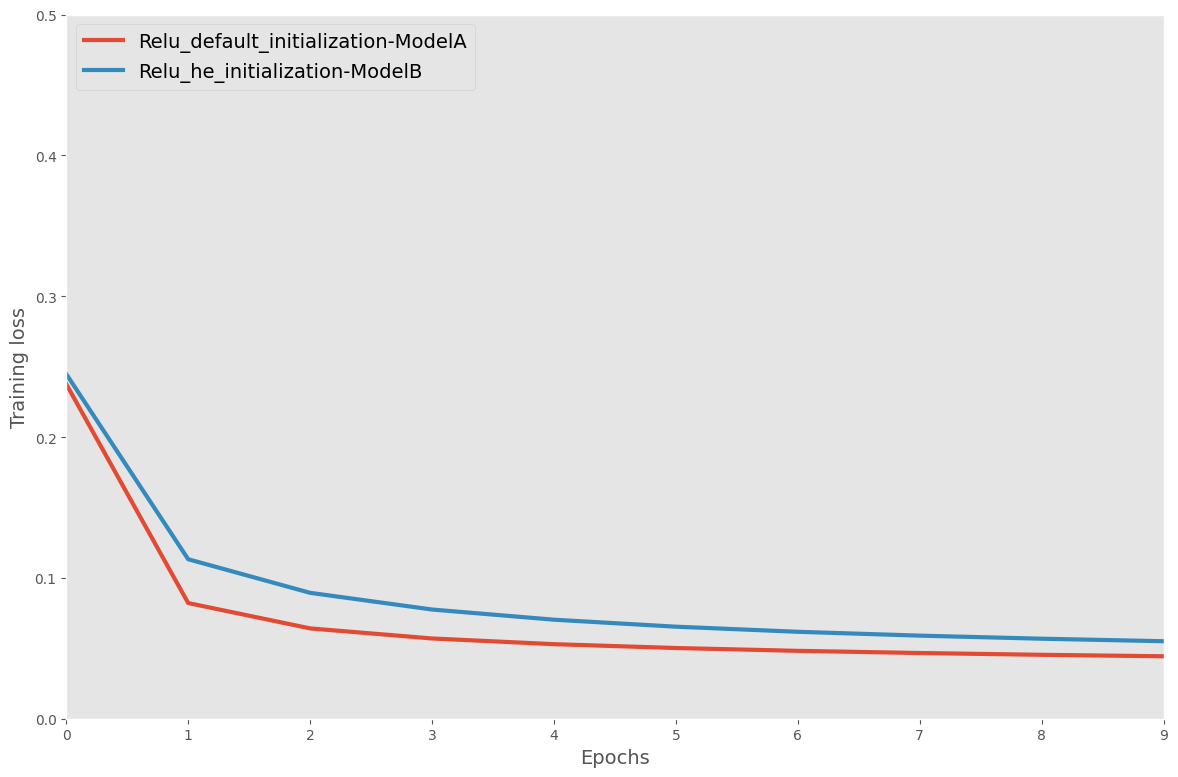

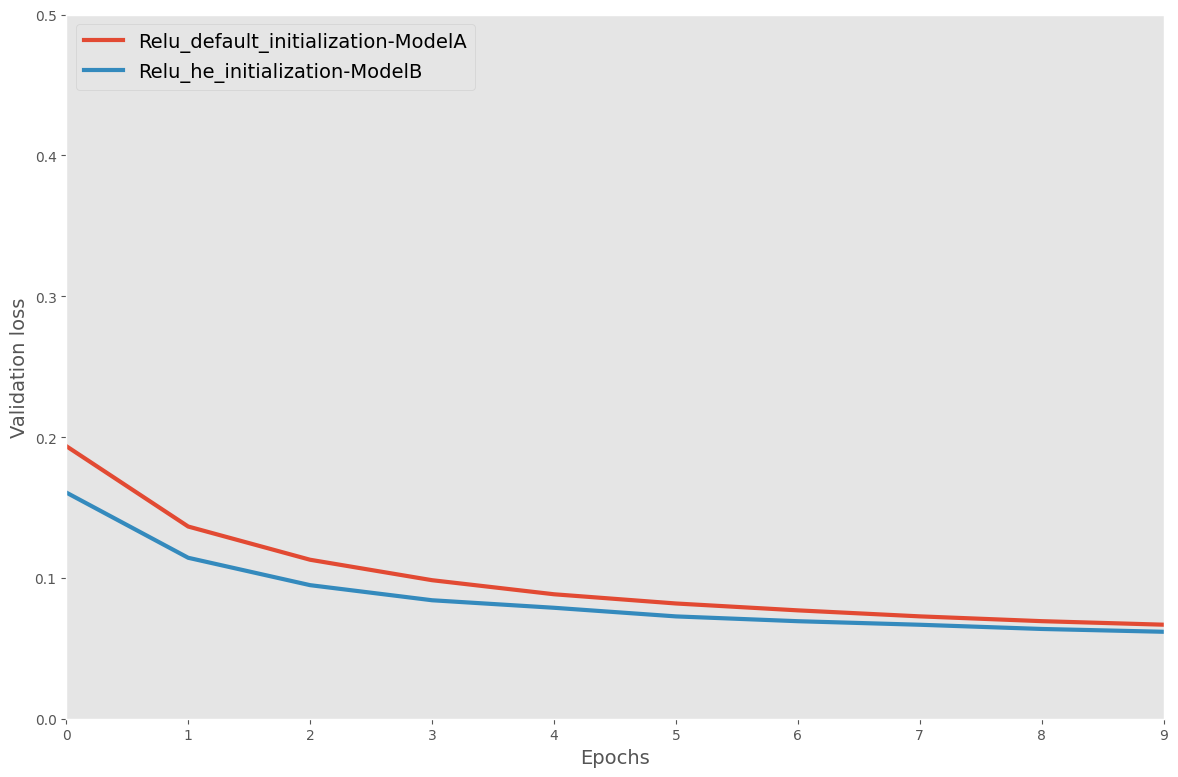

In [60]:
import tensorflow as tf

def compile_and_train_model(model):
    model.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
        metrics=["mae"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

#Initial design of the DNN with 4 dense layers

#Relu activation, default kernel_initializer glorot_uniform
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

print("Relu activation default initialization")
history_relu = compile_and_train_model(model)

#Relu activation, with He Initialization
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu",
                              kernel_initializer="he_normal"),
    tf.keras.layers.Dense(32, activation="relu",
                              kernel_initializer="he_normal"),
    tf.keras.layers.Dense(16, activation="relu",
                              kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1)
])

print("Relu activation He Initialization")
history_relu_he_initialization = compile_and_train_model(model)

#visualize the learning curves of all the optimizers

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "Relu_default_initialization-ModelA Relu_he_initialization-ModelB"
    for history, opt_name in zip((history_relu, history_relu_he_initialization),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0, 0.5])   
    save_fig("Relu_activation_"+ loss)
    plt.show()


<h3>Activation Functions in Deep Neural Networks</h3>

Use different activation functions: RELU, LeakyReLU, ELU, SELU, and Mixed activation functions to determine which has the best perfomance.

Relu baseline
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2827 - mae: 0.4131 - val_loss: 0.1669 - val_mae: 0.3033
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0912 - mae: 0.2215 - val_loss: 0.0970 - val_mae: 0.2235
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0698 - mae: 0.1862 - val_loss: 0.0771 - val_mae: 0.1948
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0611 - mae: 0.1700 - val_loss: 0.0680 - val_mae: 0.1807
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0561 - mae: 0.1598 - val_loss: 0.0625 - val_mae: 0.1715
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0528 - mae: 0.1530 - val_loss: 0.0592 - val_mae: 0.1644
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0504 - mae: 0.1477 - val_loss: 0.0568 - val_mae: 0.1611
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0486 - mae: 0.1437 - val_loss: 0.0545 - val_mae: 0.1564
Epoch 9/10
1132/1132 ━━━━━

c:\AI - UfT Course\venv\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1953 - mae: 0.3328 - val_loss: 0.0954 - val_mae: 0.2256
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0689 - mae: 0.1889 - val_loss: 0.0662 - val_mae: 0.1838
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0568 - mae: 0.1656 - val_loss: 0.0568 - val_mae: 0.1664
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0518 - mae: 0.1546 - val_loss: 0.0526 - val_mae: 0.1569
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0487 - mae: 0.1474 - val_loss: 0.0505 - val_mae: 0.1525
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0466 - mae: 0.1422 - val_loss: 0.0489 - val_mae: 0.1475
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0449 - mae: 0.1379 - val_loss: 0.0479 - val_mae: 0.1454
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0436 - mae: 0.1343 - val_loss: 0.0470 - val_mae: 0.1423
Epoch 9/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/st

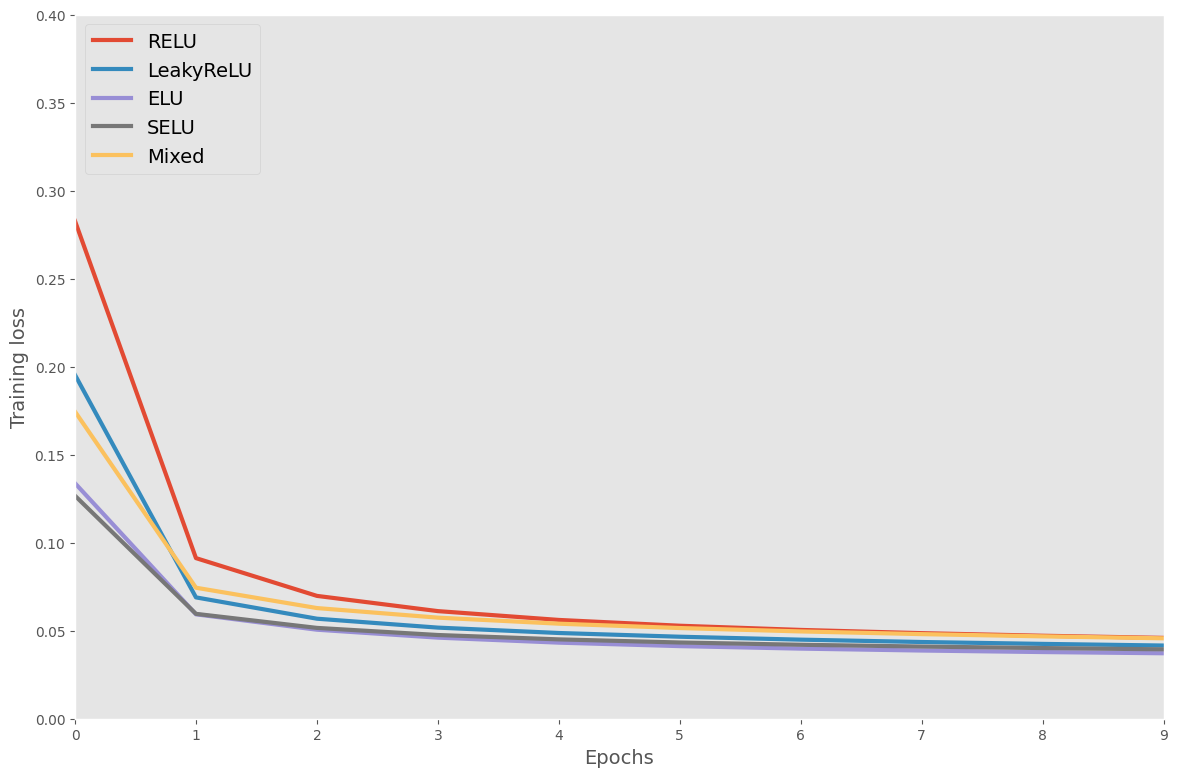

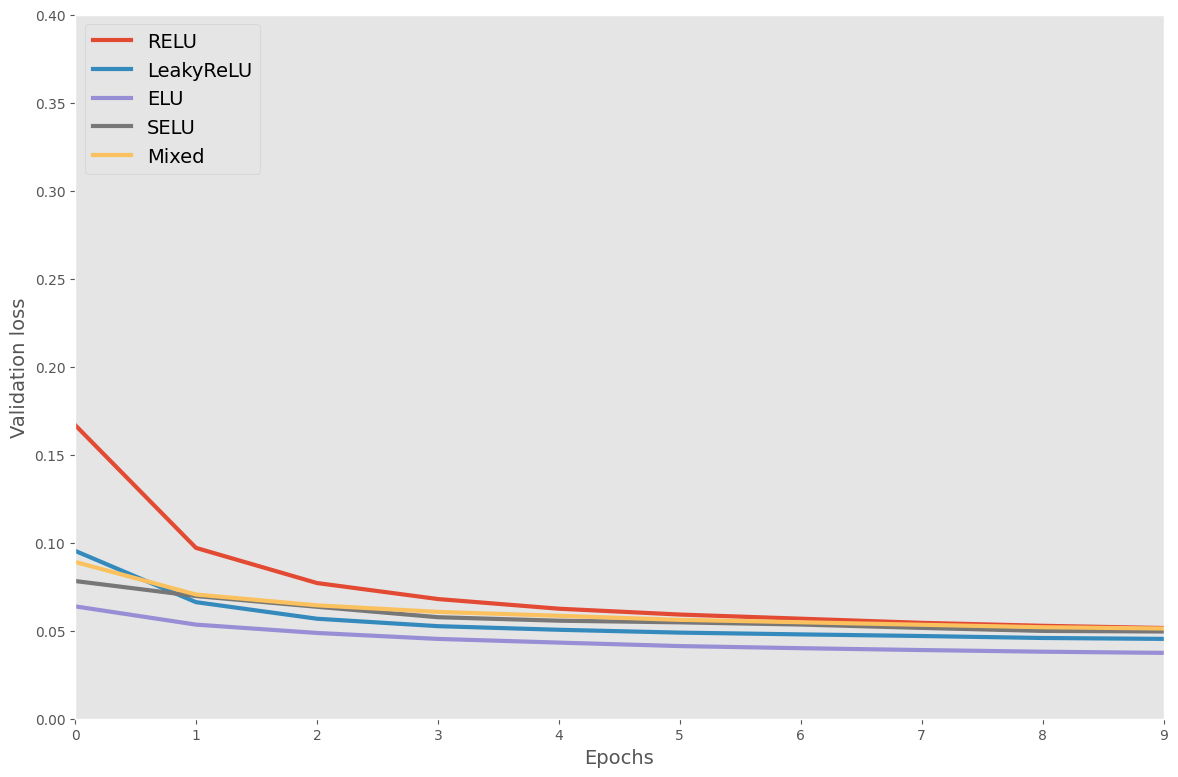

In [61]:
import tensorflow as tf

def compile_and_train_model(model):
    model.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
        metrics=["mae"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

#Relu activation - baseline
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

print("Relu baseline")
history_relu = compile_and_train_model(model)

#Leaky ReLU
leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)  # defaults to alpha=0.3

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="leaky_relu"),
    tf.keras.layers.Dense(32, activation="leaky_relu"),
    tf.keras.layers.Dense(16, activation="leaky_relu"),
    tf.keras.layers.Dense(1)
])
print("LeakyReLU")
history_leaky_relu = compile_and_train_model(model)

#ELU
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="elu"),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(16, activation="elu"),
    tf.keras.layers.Dense(1)
])
print("ELU")
history_elu = compile_and_train_model(model)

#SELU
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="selu",
                                    kernel_initializer="lecun_normal"),
    tf.keras.layers.Dense(32, activation="selu",
                                    kernel_initializer="lecun_normal"),
    tf.keras.layers.Dense(16, activation="selu",
                                    kernel_initializer="lecun_normal"),
    tf.keras.layers.Dense(1)
])
print("SELU")
history_selu = compile_and_train_model(model)

#Mixed activation functions
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"), #ReLU keeps things simple and fast
    tf.keras.layers.Dense(32, activation="elu"), #ELU in the middle can help stabilize gradients
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

print("Mixed activation functions")
history_mix = compile_and_train_model(model)


#visualize the learning curves of all models

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "RELU LeakyReLU ELU SELU Mixed"
    for history, opt_name in zip((history_relu, history_leaky_relu, 
                                  history_elu, history_selu, history_mix),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")    
    plt.axis([0, 9, 0, 0.4])
    save_fig("activation_functions_"+ loss)
    plt.show()

<h3>Optimizers in Deep Neural Networks</h3>

Train the model with different optimizers to determine which has the best performance.

SGD
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3288 - mae: 0.4468 - val_loss: 0.1559 - val_mae: 0.2992
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1052 - mae: 0.2396 - val_loss: 0.0931 - val_mae: 0.2252
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0758 - mae: 0.1980 - val_loss: 0.0733 - val_mae: 0.1953
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0645 - mae: 0.1784 - val_loss: 0.0645 - val_mae: 0.1799
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0585 - mae: 0.1664 - val_loss: 0.0593 - val_mae: 0.1698
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0545 - mae: 0.1579 - val_loss: 0.0557 - val_mae: 0.1623
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0516 - mae: 0.1513 - val_loss: 0.0530 - val_mae: 0.1563
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0494 - mae: 0.1462 - val_loss: 0.0509 - val_mae: 0.1514
Epoch 9/10
1132/1132 ━━━━━━━━━━━━━━

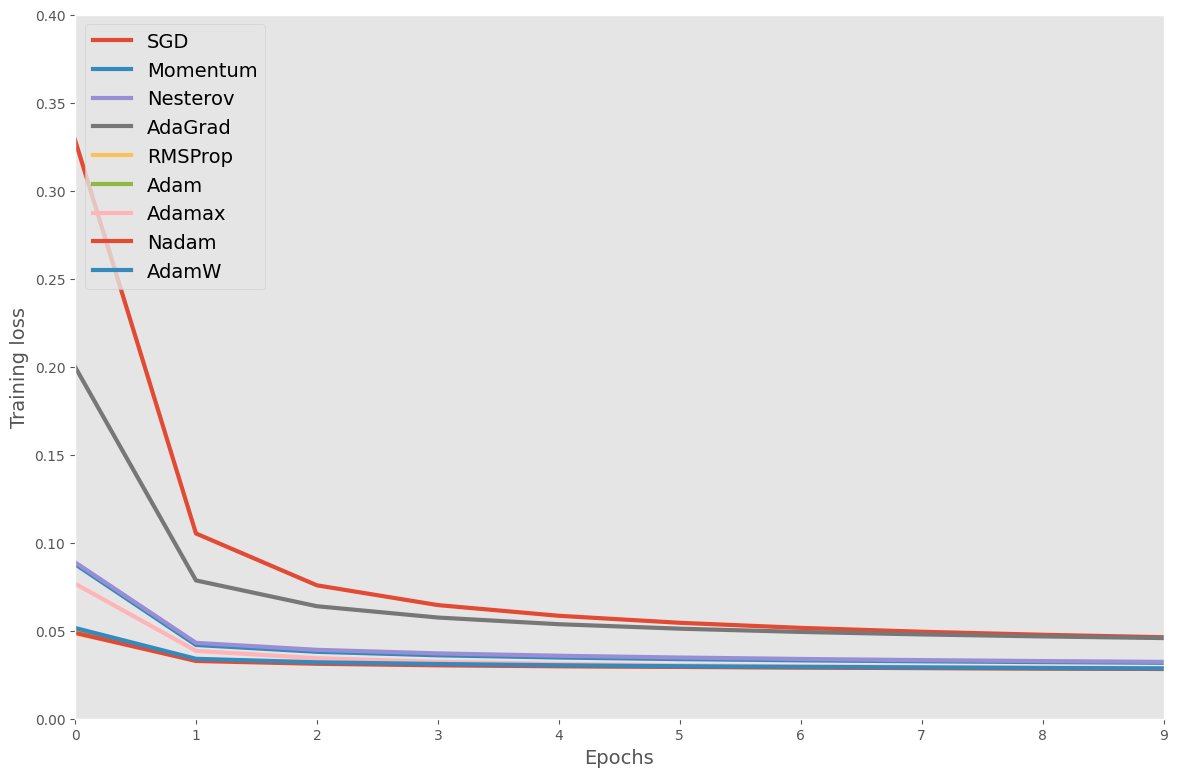

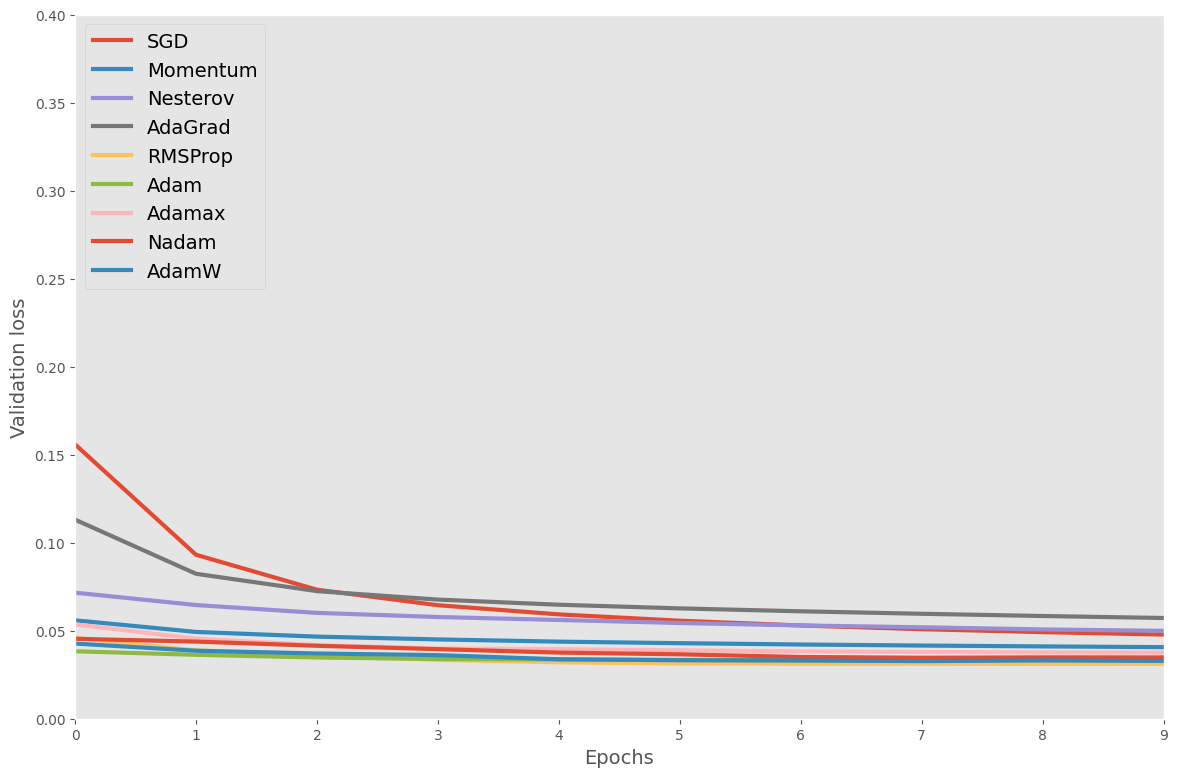

In [17]:
import tensorflow as tf

def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(
        loss="mse",
        optimizer=optimizer,
        metrics=["mae"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

# SGD optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
print("SGD")
history_sgd = build_and_train_model(optimizer) 

#SGD with momentum
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
print("SGD with momentum")
history_momentum = build_and_train_model(optimizer) 

#Nesterov Accelerated Gradient
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True)
print("Nesterov Accelerated Gradient")
history_nesterov = build_and_train_model(optimizer)  

#AdaGrad
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)
print("AdaGrad")
history_adagrad = build_and_train_model(optimizer) 

#RMSProp
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)
print("RMSProp")
history_rmsprop = build_and_train_model(optimizer)

#Adam Optimization
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9,
                                     beta_2=0.999)
print("Adam Optimization")
history_adam = build_and_train_model(optimizer)

#Adamax Optimization
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9,
                                       beta_2=0.999)
print("Adamax Optimization")
history_adamax = build_and_train_model(optimizer)

#Nadam Optimization
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9,
                                      beta_2=0.999)
print("Nadam Optimization")
history_nadam = build_and_train_model(optimizer) 

#AdamW Optimization
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001,
                                      beta_1=0.9, beta_2=0.999)
print("AdamW Optimization")
history_adamw = build_and_train_model(optimizer)

#visualize the learning curves of all the optimizers

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0, 0.4])
    save_fig("optimizers_"+ loss)
    plt.show()

<h3>Learning Rate Scheduling in Deep Neural Networks</h3>

Change the learning rate during training instead of keeping it fixed, for better performance

<h4>Power Scheduling</h4>

Power scheduling (also called polynomial decay) is a learning rate schedule where the learning rate decreases according to a power law function.

PowerSchedule
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0857 - mae: 0.1942 - val_loss: 0.0490 - val_mae: 0.1467
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0431 - mae: 0.1288 - val_loss: 0.0435 - val_mae: 0.1329
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0393 - mae: 0.1193 - val_loss: 0.0415 - val_mae: 0.1276
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0374 - mae: 0.1145 - val_loss: 0.0405 - val_mae: 0.1248
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0362 - mae: 0.1114 - val_loss: 0.0398 - val_mae: 0.1229
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0354 - mae: 0.1091 - val_loss: 0.0393 - val_mae: 0.1216
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0347 - mae: 0.1074 - val_loss: 0.0389 - val_mae: 0.1206
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0342 - mae: 0.1060 - val_loss: 0.0386 - val_mae: 0.1198
Epoch 9/10
1132/1132 ━━━━━

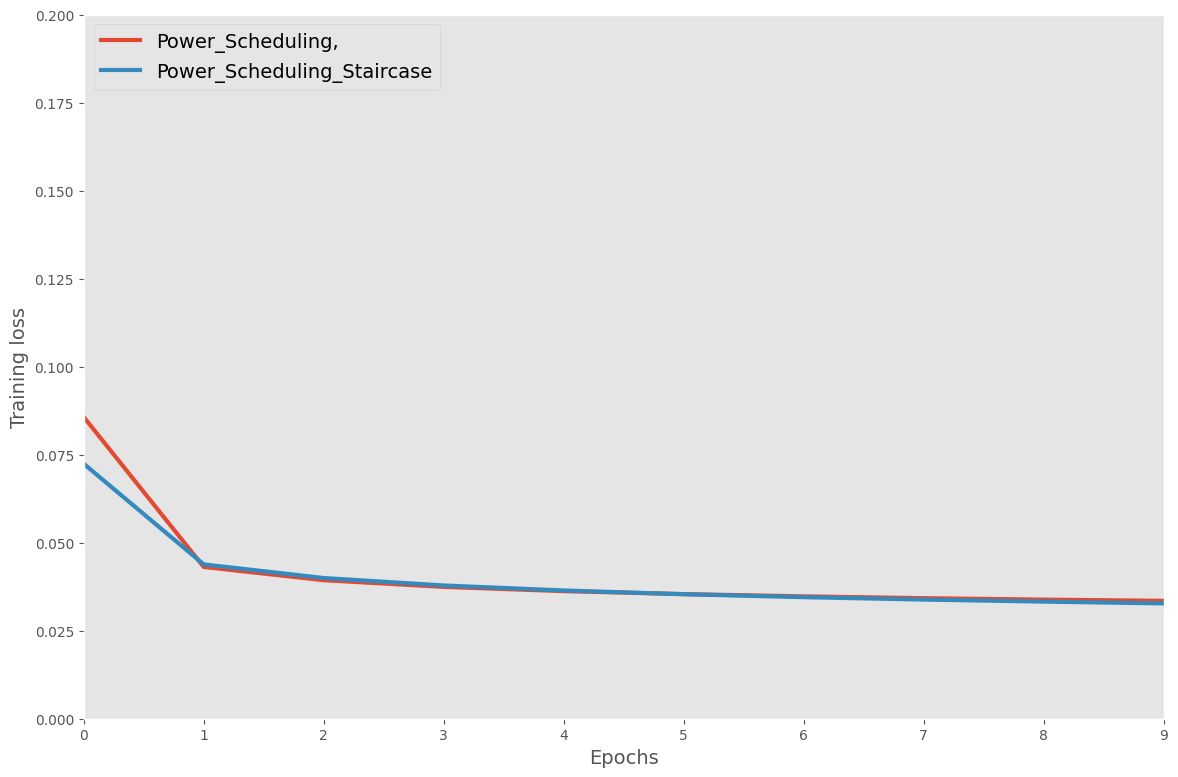

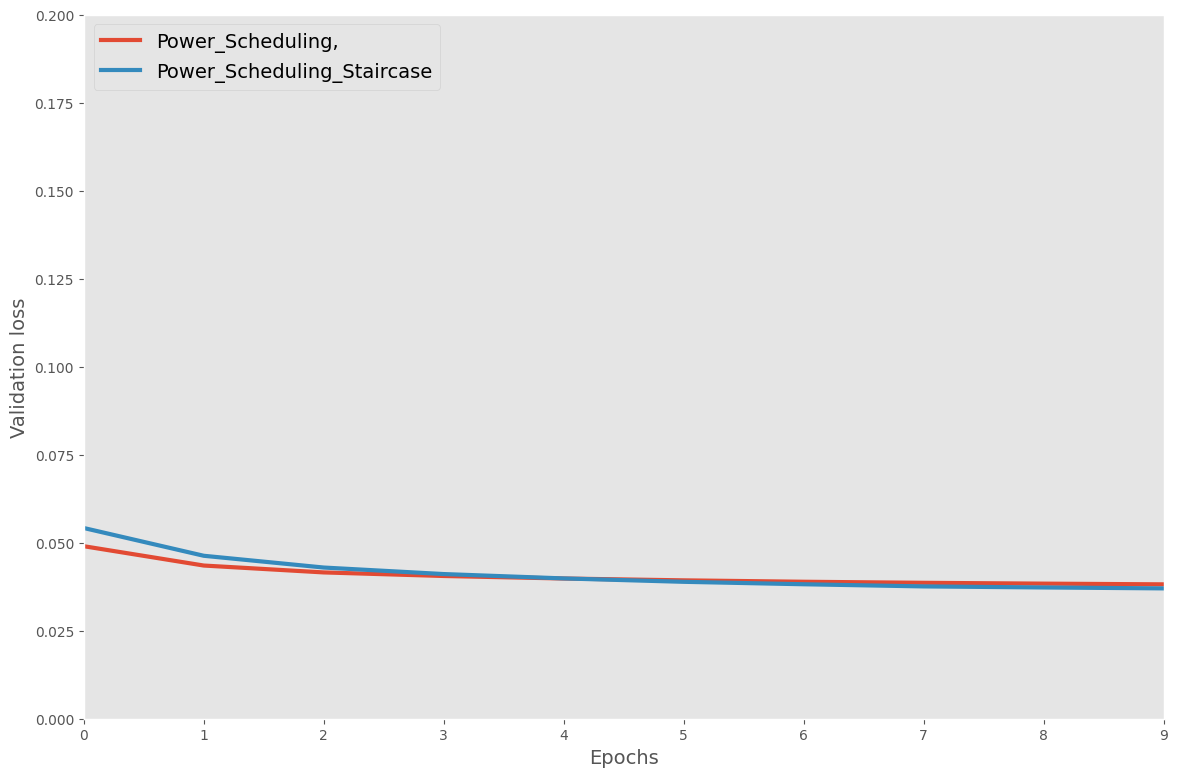

ExponentialDecay_optimized
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0426 - mae: 0.1232 - val_loss: 0.0344 - val_mae: 0.1070
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0321 - mae: 0.1014 - val_loss: 0.0320 - val_mae: 0.1011
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0296 - mae: 0.0928 - val_loss: 0.0317 - val_mae: 0.1000
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0290 - mae: 0.0909 - val_loss: 0.0313 - val_mae: 0.0967
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0286 - mae: 0.0893 - val_loss: 0.0312 - val_mae: 0.0963
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0283 - mae: 0.0883 - val_loss: 0.0312 - val_mae: 0.0953
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0280 - mae: 0.0877 - val_loss: 0.0312 - val_mae: 0.0953
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0278 - mae: 0.0869 - val_loss: 0.0312 - val_mae: 0.0951
Epoch 9/10
11

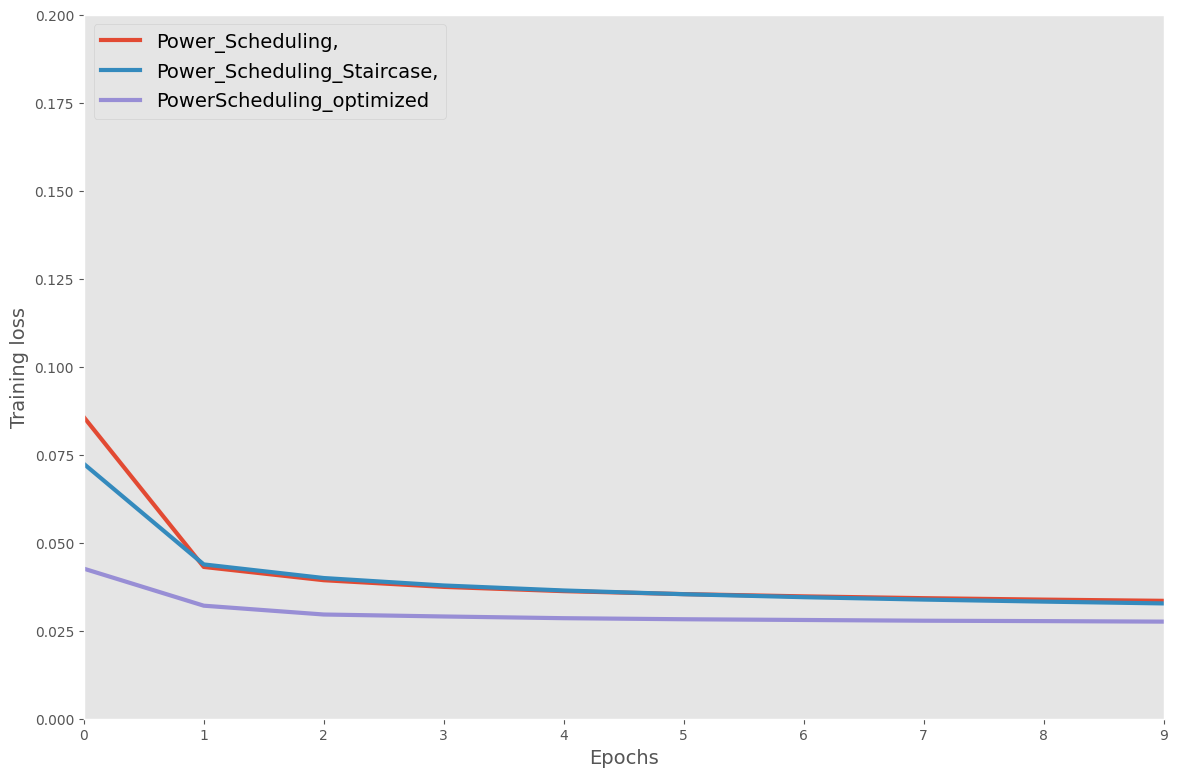

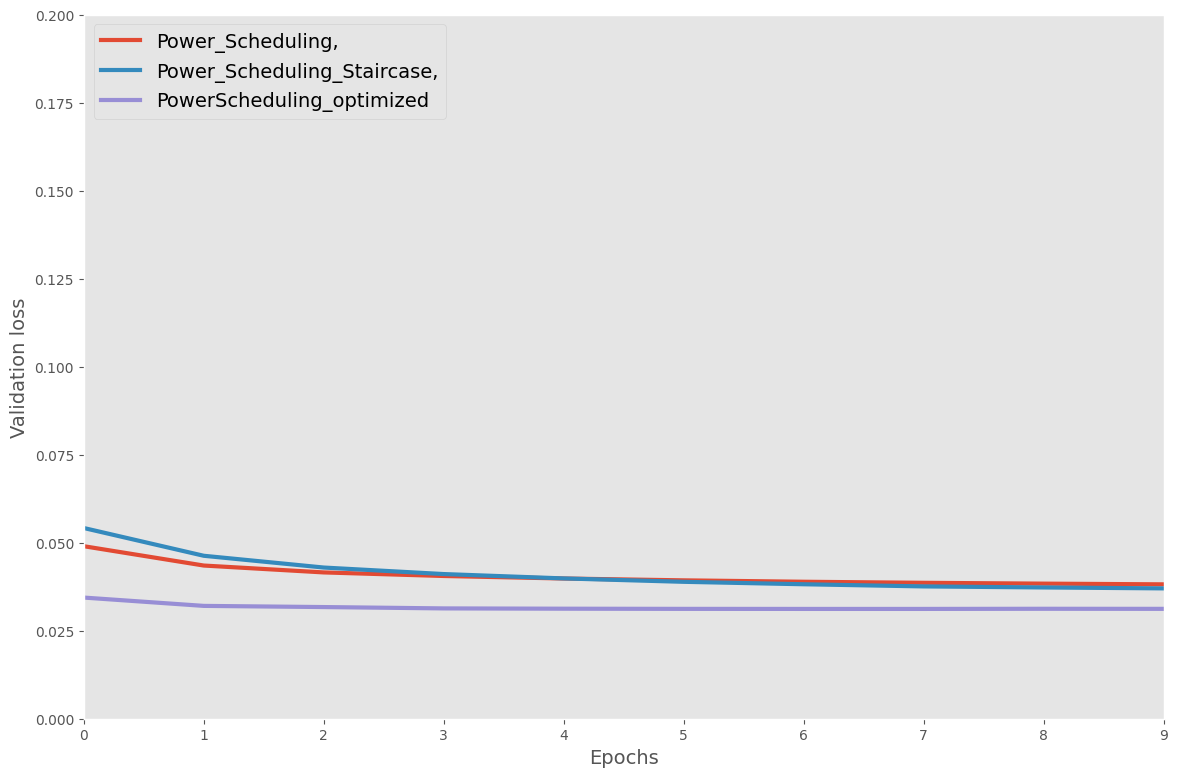

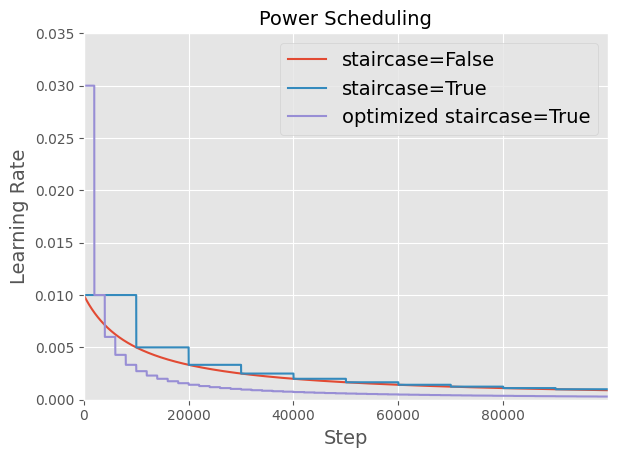

In [ ]:
import tensorflow as tf

def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(
        loss="mse",
        optimizer=optimizer,
        metrics=["mae"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

#Start with guessed hyperparameters: initial_learning_rate, decay_steps, decay_rate
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

print("PowerSchedule")
history_power_schedule = build_and_train_model(optimizer)

lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=True
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

print("PowerSchedule_Staircase")
history_power_schedule_staircase = build_and_train_model(optimizer)

#visualize the learning curves

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "Power_Scheduling, Power_Scheduling_Staircase"
    for history, opt_name in zip((history_power_schedule, 
                                  history_power_schedule_staircase),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0, 0.2])
    save_fig("power_scheduling_learning_curve_"+ loss)
    plt.show()


#Analyse the results and fine tune the hyperparameters for better performance
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.03,
    decay_steps=2000,
    decay_rate=2.0,
    staircase=True
)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=lr_schedule,
    momentum=0.9,
    nesterov=True
) 

print("ExponentialDecay_optimized")
history_power_scheduling_optimized = build_and_train_model(optimizer)

#visualize the learning curves

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "Power_Scheduling, Power_Scheduling_Staircase, PowerScheduling_optimized"
    for history, opt_name in zip((history_power_schedule, 
                                  history_power_schedule_staircase,
                                  history_power_scheduling_optimized),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0, 0.2])
    save_fig("power_scheduling_learning_curve_"+ loss)
    plt.show()

# Visualize the learning rate
initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

initial_learning_rate_optimized = 0.03
decay_steps_optimized = 2000
decay_rate_optimized = 2.0

steps = np.arange(100_000)

# Smooth inverse time decay
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)

# Staircase inverse time decay
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

# Optimized staircase inverse time decay
lrs3 = initial_learning_rate_optimized / (
    1 + decay_rate_optimized * np.floor(steps / decay_steps_optimized)
)

plt.plot(steps, lrs, "-", label="staircase=False")
plt.plot(steps, lrs2, "-", label="staircase=True")
plt.plot(steps, lrs3, "-", label="optimized staircase=True")

plt.axis([0, steps.max(), 0, 0.035])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
save_fig("power_scheduling")
plt.show()

<h4>Exponential Scheduling</h4>

Exponential scheduling is a learning rate decay strategy where the learning rate is reduced multiplicatively after each epoch (or step). 

ExponentialDecay
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0728 - mae: 0.1794 - val_loss: 0.0543 - val_mae: 0.1577
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0437 - mae: 0.1306 - val_loss: 0.0459 - val_mae: 0.1406
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0397 - mae: 0.1212 - val_loss: 0.0428 - val_mae: 0.1341
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0378 - mae: 0.1164 - val_loss: 0.0412 - val_mae: 0.1304
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0366 - mae: 0.1133 - val_loss: 0.0402 - val_mae: 0.1280
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0358 - mae: 0.1112 - val_loss: 0.0395 - val_mae: 0.1262
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0351 - mae: 0.1096 - val_loss: 0.0390 - val_mae: 0.1248
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0347 - mae: 0.1084 - val_loss: 0.0386 - val_mae: 0.1237
Epoch 9/10
1132/1132 ━━

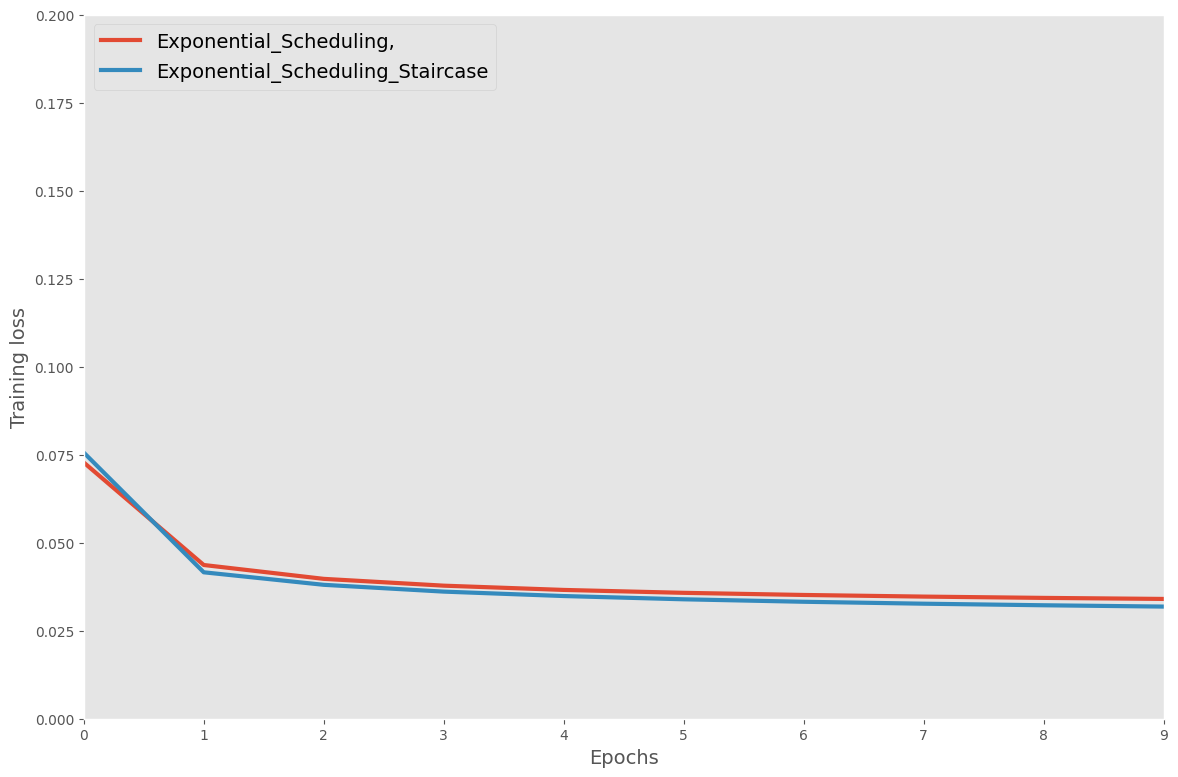

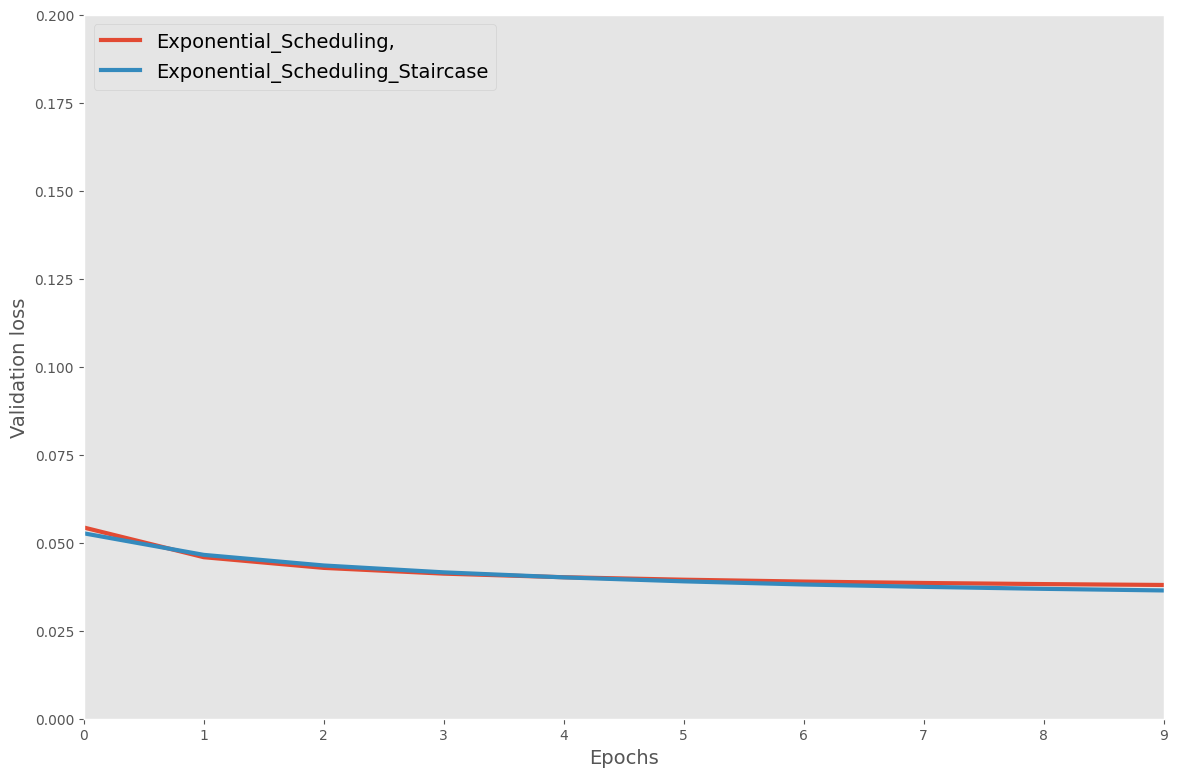

ExponentialDecay_optimized
Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0415 - mae: 0.1230 - val_loss: 0.0340 - val_mae: 0.1069
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0322 - mae: 0.1017 - val_loss: 0.0326 - val_mae: 0.1028
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0300 - mae: 0.0943 - val_loss: 0.0326 - val_mae: 0.1021
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0293 - mae: 0.0917 - val_loss: 0.0322 - val_mae: 0.1004
Epoch 5/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0286 - mae: 0.0893 - val_loss: 0.0321 - val_mae: 0.1003
Epoch 6/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0282 - mae: 0.0875 - val_loss: 0.0315 - val_mae: 0.0977
Epoch 7/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0279 - mae: 0.0865 - val_loss: 0.0316 - val_mae: 0.0979
Epoch 8/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0277 - mae: 0.0854 - val_loss: 0.0314 - val_mae: 0.0976
Epoch 9/10
11

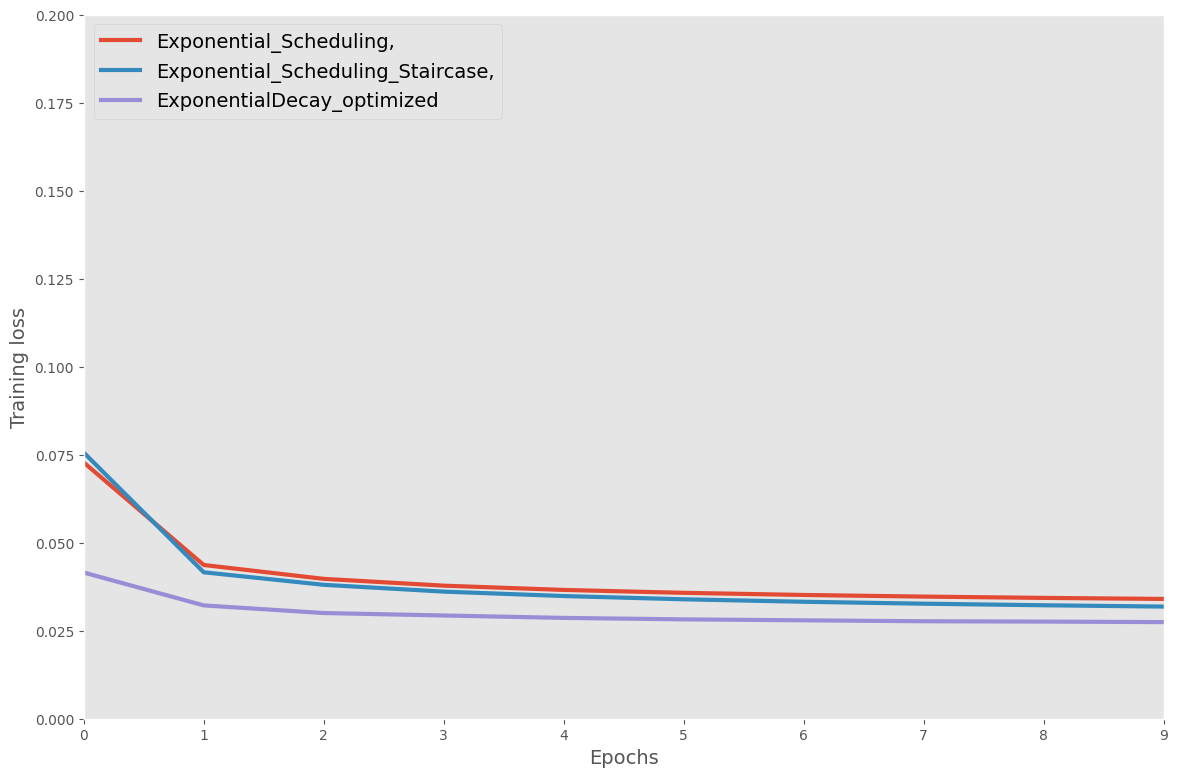

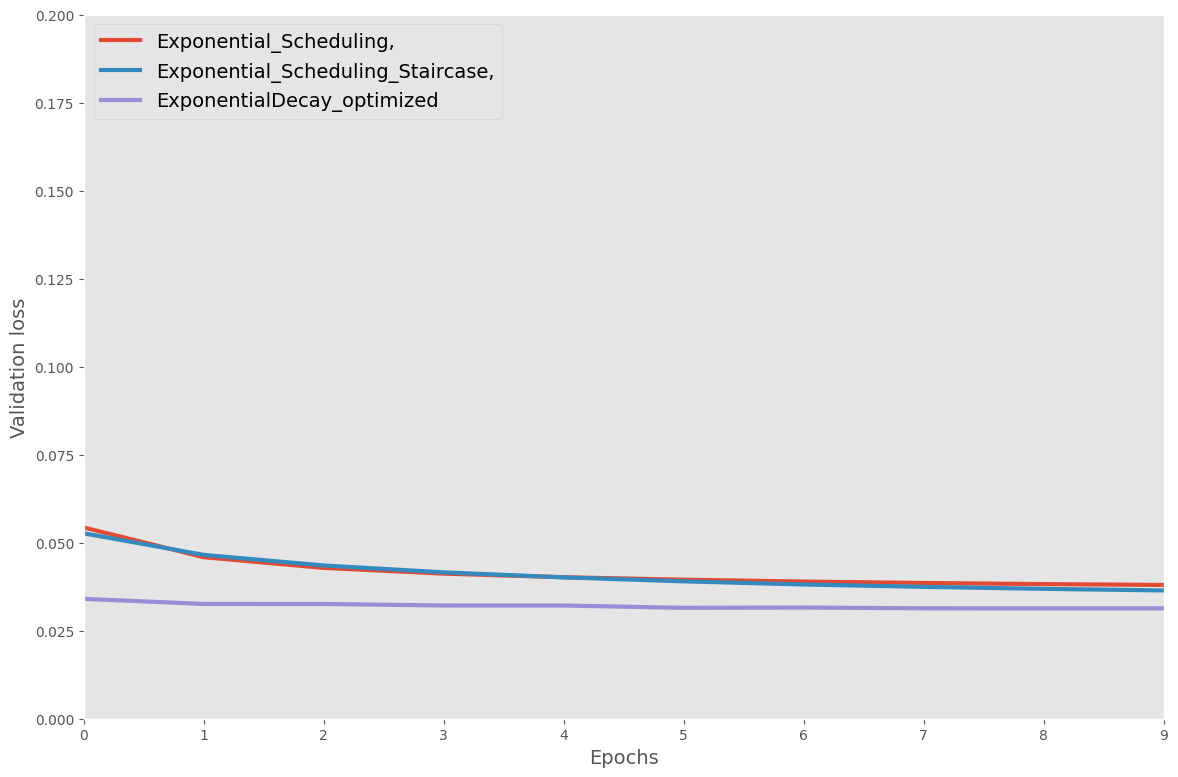

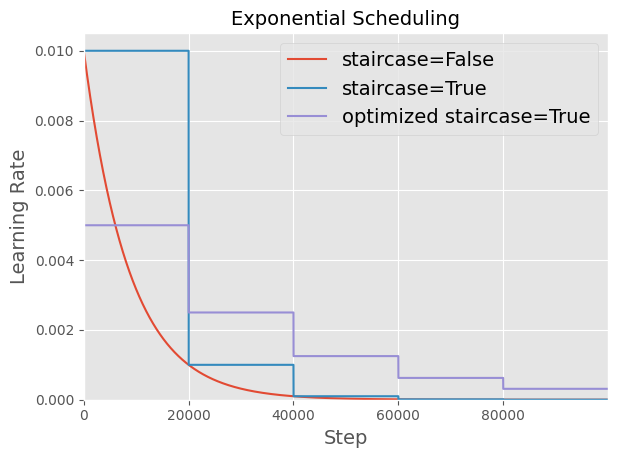

In [19]:
import tensorflow as tf

def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(
        loss="mse",
        optimizer=optimizer,
        metrics=["mae"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

#Start with guessed hyperparameters: initial_learning_rate, decay_steps, decay_rate
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

print("ExponentialDecay")
history_exponential_scheduling = build_and_train_model(optimizer)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=True
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

print("ExponentialDecay_Staircase")
history_exponential_scheduling_staircase = build_and_train_model(optimizer)

#visualize the learning curves

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "Exponential_Scheduling, Exponential_Scheduling_Staircase"
    for history, opt_name in zip((history_exponential_scheduling, 
                                  history_exponential_scheduling_staircase),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0, 0.2])
    save_fig("exponential_learning_curve_"+ loss)
    plt.show()


#Analyse the results and fine tune the hyperparameters for better performance
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.03,
    decay_steps=2000,
    decay_rate=0.5,
    staircase=True
)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=lr_schedule,
    momentum=0.9,
    nesterov=True
) 

print("ExponentialDecay_optimized")
history_exponential_decay_optimized = build_and_train_model(optimizer)

#visualize the learning curves

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "Exponential_Scheduling, Exponential_Scheduling_Staircase, ExponentialDecay_optimized"
    for history, opt_name in zip((history_exponential_scheduling, 
                                  history_exponential_scheduling_staircase,
                                  history_exponential_decay_optimized),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0, 0.2])
    save_fig("exponential_learning_curve_"+ loss)
    plt.show()

#Visualize the learning rate
initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

initial_learning_rate_optimized = 0.005
decay_rate_optimized = 0.5
decay_steps_optimized = 1500

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)
lrs3 = initial_learning_rate_optimized * decay_rate_optimized ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.plot(steps, lrs3,  "-", label="optimized staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
save_fig("exponential_scheduling")
plt.show()

<h3>Early Stopping</h3>

Early Stopping is a training technique where the model stops training automatically when it stops improving on the validation set, ensuring we get the best weights without wasting time or overfitting.

Baseline
Epoch 1/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0698 - mae: 0.1681 - val_loss: 0.0456 - val_mae: 0.1382
Epoch 2/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0378 - mae: 0.1164 - val_loss: 0.0397 - val_mae: 0.1242
Epoch 3/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0338 - mae: 0.1064 - val_loss: 0.0372 - val_mae: 0.1175
Epoch 4/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0320 - mae: 0.1014 - val_loss: 0.0358 - val_mae: 0.1134
Epoch 5/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0310 - mae: 0.0983 - val_loss: 0.0350 - val_mae: 0.1110
Epoch 6/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0303 - mae: 0.0962 - val_loss: 0.0346 - val_mae: 0.1094
Epoch 7/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0298 - mae: 0.0947 - val_loss: 0.0344 - val_mae: 0.1085
Epoch 8/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0294 - mae: 0.0935 - val_loss: 0.0343 - val_mae: 0.1081
Epoch 9/50
1132/1132 ━━━━━━━━━━

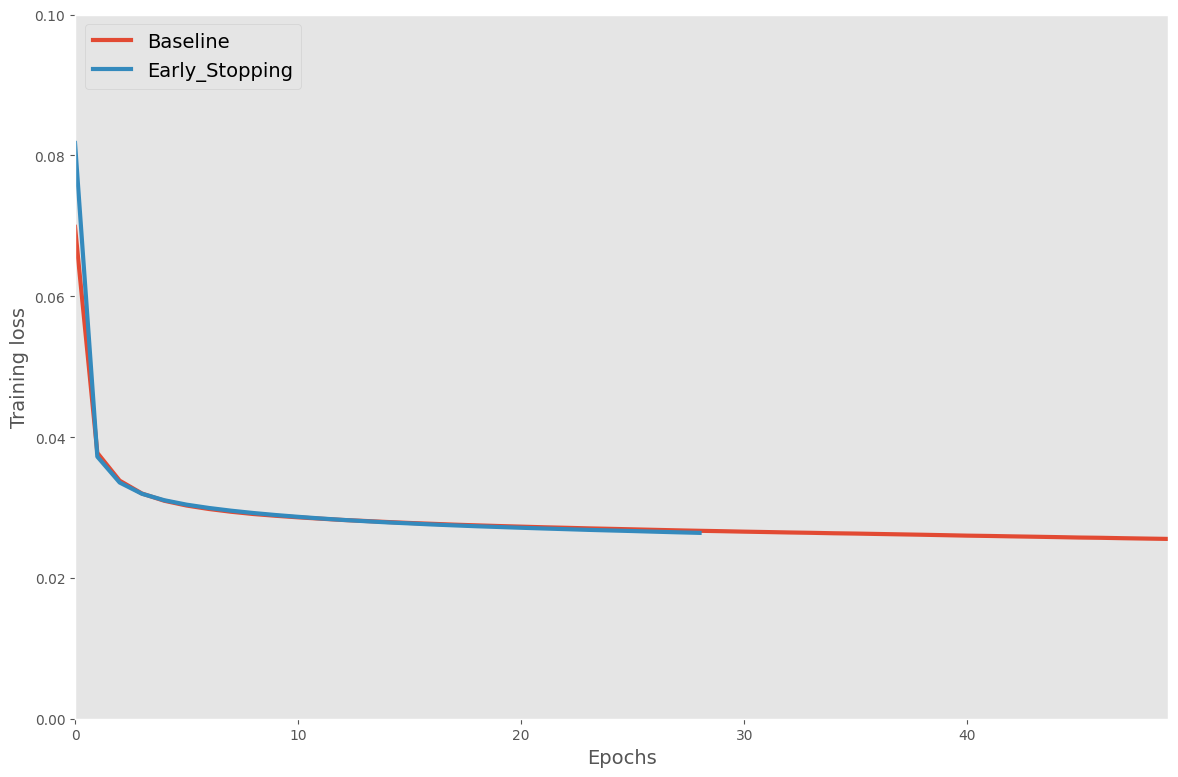

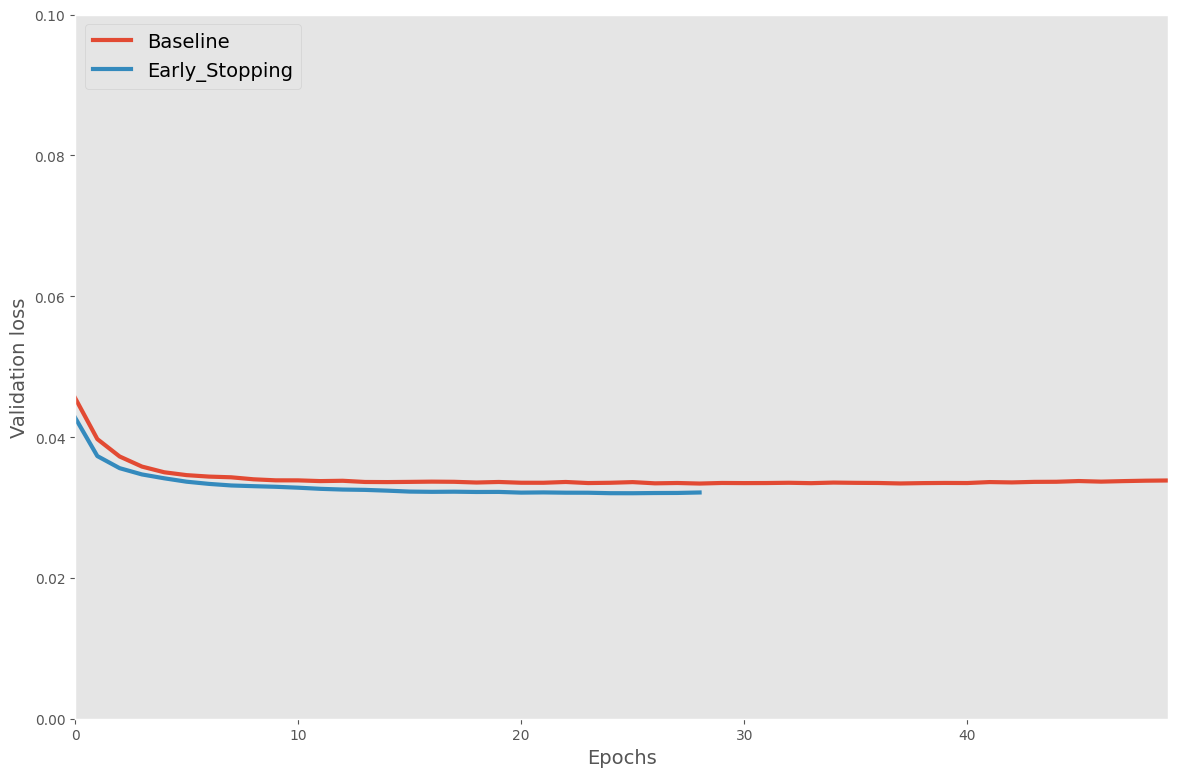

In [ ]:
import tensorflow as tf

def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

def build_and_train_model(optimizer, callbacks=None):
    model = build_model()
    model.compile(
        loss="mse",
        optimizer=optimizer,
        metrics=["mae"]
    )
    return model.fit(
        X_train, y_train,
        epochs=50,                      
        validation_data=(X_valid, y_valid),
        callbacks=callbacks
    )

optimizer_baseline = tf.keras.optimizers.Adamax(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999
)
#Baseline
print("Baseline")
history_baseline = build_and_train_model(optimizer_baseline)

#Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,               
    restore_best_weights=True
)
# stop after 3 epochs with no improvement

optimizer_es = tf.keras.optimizers.Adamax(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999
)

print("With EarlyStopping")
history_es = build_and_train_model(optimizer_es, callbacks=[early_stopping])

print("Baseline final val_loss:", history_baseline.history["val_loss"][-1])
print("EarlyStopping best val_loss:", min(history_es.history["val_loss"]))
print("EarlyStopping stopped at epoch:", len(history_es.history["loss"]))


#visualize the learning curves 

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "Baseline Early_Stopping"
    for history, opt_name in zip((history_baseline, history_es),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 49, 0, 0.1])    
    save_fig("early_stopping_"+ loss)
    plt.show()